In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from pathlib import Path
import equinox as eqx
import numpy as np
from matplotlib import animation

from utilities import Params, integrate_vector_field
from vector_fields import vector_field_three_body_plummer, vector_field_hnn_potenergy
from models import HamiltonianNN

In [40]:
seed = 42
key = jax.random.PRNGKey(seed)
EPSILONS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
N_INITIAL_CONDITIONS = 64
# CKPT_DIR = Path("checkpoints/epsilon_range_test")
CKPT_DIR = Path("checkpoints/plummersoftening/epsilon_range_test_larger_model")

In [41]:
# model_test = HamiltonianNN(key=key, input_dim=9, hidden_dim=128, depth=5)
# params, static = eqx.partition(model_test, eqx.is_array)

In [42]:
 
# def count_parameters(param_tree):
#     """Return total number of trainable parameters in a JAX/Flax param pytree."""
#     leaves = jax.tree_util.tree_leaves(param_tree)
#     return sum(int(jnp.prod(jnp.array(leaf.shape))) for leaf in leaves)
 
# nparams = count_parameters(params)
# print(f"Total number of trainable parameters: {nparams}")

In [44]:
# model_save_name = "hnn_potenergy_three_body"
model_save_name = "hnn_pot_three_body_rel_dist_800ep_lr_decay"

In [45]:
def load_model(epsilon: float, model_save_name: str, model_like, aux_like=None) -> tuple:
    """
    Load the trained HNN corresponding to this epsilon.
    """
    eps_tag = f"eps_{epsilon:.1f}".replace(".", "-")
    model_path = CKPT_DIR / eps_tag / f"{model_save_name}_model.eqx"
    aux_path   = CKPT_DIR / eps_tag / f"{model_save_name}_aux.eqx" 

    model = eqx.tree_deserialise_leaves(model_path, model_like)
    aux = None
    if aux_path.exists() and aux_like is not None:
        aux = eqx.tree_deserialise_leaves(aux_path, aux_like)

    return model, aux

In [46]:
def zero_total_momentum(v, masses):
    """
    v: array (..., n_bodies, dim) velocities
    masses: array (n_bodies,)
    returns v' with sum_i m_i v'_i = 0
    """
    M = jnp.sum(masses)
    V_cm = jnp.tensordot(masses, v, axes=(0, -2)) / M   # (..., dim)
    return v - V_cm[... , None, :] 

In [47]:
def sample_ic_batch(key: jax.random.PRNGKey, system_params: Params, N: int):
    """
    Samples initial conditions for the 3D triangular 3-mass system.

    Returns shape (N, 18):
    [x0, y0, z0, x1, y1, z1, x2, y2, z2,
     vx0, vy0, vz0, vx1, vy1, vz1, vx2, vy2, vz2]
    """
    masses = jnp.array([system_params.m0, system_params.m1, system_params.m2])

    # Split keys
    key0, key1, key2, key3, keyz = jax.random.split(key, 5)

    # --- Base triangular layout (roughly upright triangle in x–y) ---

    # Mass 0 near top
    x0 = jax.random.uniform(key0, (N,), minval=0.3, maxval=0.7)
    y0 = jax.random.uniform(key0, (N,), minval=1.0, maxval=1.4)

    # Mass 1 bottom-left region
    x1 = jax.random.uniform(key1, (N,), minval=0.1, maxval=0.4)
    y1 = jax.random.uniform(key1, (N,), minval=0.1, maxval=0.5)

    # Mass 2 bottom-right region
    x2 = jax.random.uniform(key2, (N,), minval=0.6, maxval=0.9)
    y2 = jax.random.uniform(key2, (N,), minval=0.1, maxval=0.5)

    # z-coordinates: small perturbations around 0 (near a plane)
    z0 = jax.random.uniform(keyz, (N,), minval=-0.5, maxval=0.5)
    z1 = jax.random.uniform(keyz, (N,), minval=-0.5, maxval=0.5)
    z2 = jax.random.uniform(keyz, (N,), minval=-0.5, maxval=0.5)

    # Stack positions: (N, 9)
    r = jnp.stack([x0, y0, z0,
                   x1, y1, z1,
                   x2, y2, z2], axis=-1)

    # Recenter center of mass to origin
    r_reshaped = r.reshape(N, 3, 3)               # (N, n_bodies, dim)
    total_mass = jnp.sum(masses)
    r_cm = (masses[None, :, None] * r_reshaped).sum(axis=1, keepdims=True) / total_mass
    r_reshaped = r_reshaped - r_cm                # shift COM to origin
    r = r_reshaped.reshape(N, 9)

    # Zero total momentum
    v = jax.random.uniform(key3, (N, 9), minval=-0.3, maxval=0.3)
    v_reshaped = v.reshape(N, 3, 3)
    v_zero = jax.vmap(zero_total_momentum, in_axes=(0, None))(v_reshaped, masses)
    v = v_zero.reshape(N, 9)

    # Return concatenated state: (N, 18)
    return jnp.concatenate([r, v], axis=-1)

In [48]:
def true_trajectories(ic_batch, t0, t1, num_steps, eps, system_params):
    """
    ic_batch: [N, dim_y]
    returns: t_eval [T], y_true [N, T, dim_y]
    """
    t_eval = jnp.linspace(t0, t1, num_steps)

    solve_batch = integrate_vector_field(ts=t_eval, term=vector_field_three_body_plummer, eps=eps)

    ys_true = solve_batch(model=None, params=system_params, y0s=ic_batch)
    return t_eval, ys_true

In [49]:
def predict_hnn_trajectories(model, ic_batch, t0, t1, num_steps, eps, system_params):
    """
    ic_batch: [N, dim_y]
    returns: y_pred [N, T, dim_y]
    """
    t_eval = jnp.linspace(t0, t1, num_steps)

    solve_batch = integrate_vector_field(ts=t_eval, term=vector_field_hnn_potenergy, eps=eps)

    ys_pred = solve_batch(model=model, params=system_params, y0s=ic_batch)
    return ys_pred

In [50]:
system_params = Params(m0=1.0, m1=1.0, m2=1.0, G=1.0)
T0 = 0.0
T1 = 10.0
NUM_STEPS = 5001
NUM_TRAJECTORIES = 128

In [51]:
def compute_traj_mse(y_true, y_pred):
    """
    y_true, y_pred: [N, T, dim]
    returns: [N] MSE per trajectory
    """
    return jnp.mean((y_true - y_pred) ** 2, axis=(1, 2))

In [52]:
def compute_traj_mse(y_true, y_pred):
    """
    y_true, y_pred: [N, T, dim]
    returns: [N] MSE per trajectory
    """
    return jnp.mean((y_true - y_pred) ** 2, axis=(1, 2))

In [53]:
def compute_error_growth_rates(
    y_true,       # [N, T, dim]
    y_pred,       # [N, T, dim]
    t_eval,       # [T]
    t_fit_max,    # use only times t <= t_fit_max for the fit
    min_error=1e-12,  # to avoid log(0)
):
    """
    Return λ_eff per trajectory by fitting log(error) ≈ a + λ t on early times.

    y_true, y_pred: np.ndarray, shape [N, T, dim]
    t_eval: np.ndarray, shape [T]
    t_fit_max: float, maximum time to include in the fit (e.g. 2.0)
    min_error: float, floor for errors before taking log

    returns:
        lambdas: np.ndarray, shape [N], λ_eff per trajectory
    """
    N, T, dim = y_true.shape

    # 1. restrict to early window t <= t_fit_max
    mask = t_eval <= t_fit_max
    t_fit = t_eval[mask]                  # [T_fit]
    if t_fit.size < 2:
        raise ValueError("t_fit_max too small; need at least 2 time points.")

    # 2. compute error norm e(t) per trajectory
    #    here: use full state; you can restrict to positions if you prefer
    diff = y_true[:, mask, :] - y_pred[:, mask, :]  # [N, T_fit, dim]
    e_t = np.linalg.norm(diff, axis=-1)             # [N, T_fit]

    # 3. avoid log(0) by flooring at min_error
    e_t = np.maximum(e_t, min_error)

    # 4. fit log(e_t) = a + λ t for each trajectory
    lambdas = np.empty(N, dtype=float)

    for i in range(N):
        y_log = np.log(e_t[i])      # [T_fit]
        # linear fit: y_log ≈ a + λ t
        # polyfit returns [λ, a]
        λ, a = np.polyfit(t_fit, y_log, deg=1)
        lambdas[i] = λ

    return lambdas

In [54]:
def run_epsilon_range_test(key, model_save_name, model_like, save_path):

    for eps in EPSILONS:
        print(f"Evaluating epsilon={eps}")

        # 1. Load model
        model, aux = load_model(epsilon=eps, model_save_name=model_save_name, model_like=model_like)

        # 2. Sample ICs
        key, subkey = jax.random.split(key)
        y0s = sample_ic_batch(subkey, system_params, NUM_TRAJECTORIES)

        # 3. Rollout true trajectories
        t_eval, y_true = true_trajectories(y0s, T0, T1, NUM_STEPS, eps=eps, system_params=system_params)

        # 4. Rollout model trajectories
        y_pred = predict_hnn_trajectories(model, y0s, T0, T1, NUM_STEPS, eps=eps, system_params=system_params)

        # 5. Compute per-trajectory errors
        traj_mse = compute_traj_mse(y_true, y_pred)  # [N_IC]

        # 6. compute λ_eff per trajectory
        lambdas = compute_error_growth_rates(
            np.array(y_true),
            np.array(y_pred),
            np.array(t_eval),
            t_fit_max=0.2*T1,       # choose based on your time horizon, maybe 10–20% of T1
            min_error=1e-10,
        )

        # 6. Save results for this epsilon
        eps_tag = f"{eps:.1f}".replace(".", "-")
        out_path = save_path / f"eps_{eps_tag}_results.npz"

        np.savez(
            out_path,
            epsilon=np.array(eps),
            t_eval=np.array(t_eval),
            ic_batch=np.array(y0s),
            y_true=np.array(y_true),
            y_pred=np.array(y_pred),
            traj_mse=np.array(traj_mse),
            lambdas=np.array(lambdas),
        )
        print(f"Saved {out_path} | mean MSE = {float(traj_mse.mean()):.3e}")

In [62]:
key, subkey = jax.random.split(key)
# model_like = HamiltonianNN(key=subkey, input_dim=18, hidden_dim=128, depth=4, relative_distances=True)
model_like = HamiltonianNN(key=subkey, input_dim=18, hidden_dim=128, depth=4, relative_distances=False)

In [63]:
run_epsilon_range_test(key, model_save_name, model_like=model_like, save_path=CKPT_DIR/"results")

Evaluating epsilon=0.1


TreePathError: Error at leaf with path (GetAttrKey(name='relative_distances'),)

# Load errors and plot results

In [21]:
def load_all_errors(results_dir):
    epsilons = []
    all_errors = []  # list of [N_IC] arrays

    for npz_file in sorted(results_dir.glob("eps_*_results.npz")):
        data = np.load(npz_file)
        eps = float(data["epsilon"])
        mse = data["traj_mse"]  # [N_IC]
        epsilons.append(eps)
        all_errors.append(mse)

    epsilons = np.array(epsilons)
    # all_errors becomes [n_eps, N_IC]
    errors = np.stack(all_errors, axis=0)
    return epsilons, errors

In [22]:
epsilons, errors = load_all_errors(results_dir= CKPT_DIR / "results")
print("epsilons:", epsilons)
print("errors shape:", errors.shape) 

epsilons: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
errors shape: (10, 128)


In [23]:
# Font settings
plt.rcParams['font.size'] = 22
plt.rcParams['font.family'] = 'sans-serif'

# Color palette
COLORS = {
    "dark_blue": "#2160B3",   
    "light_blue": "#74c6ec",     
    "yellow": "#f0c37c",
    "orange": "#D27146",
    "grey": "#777777",      
}

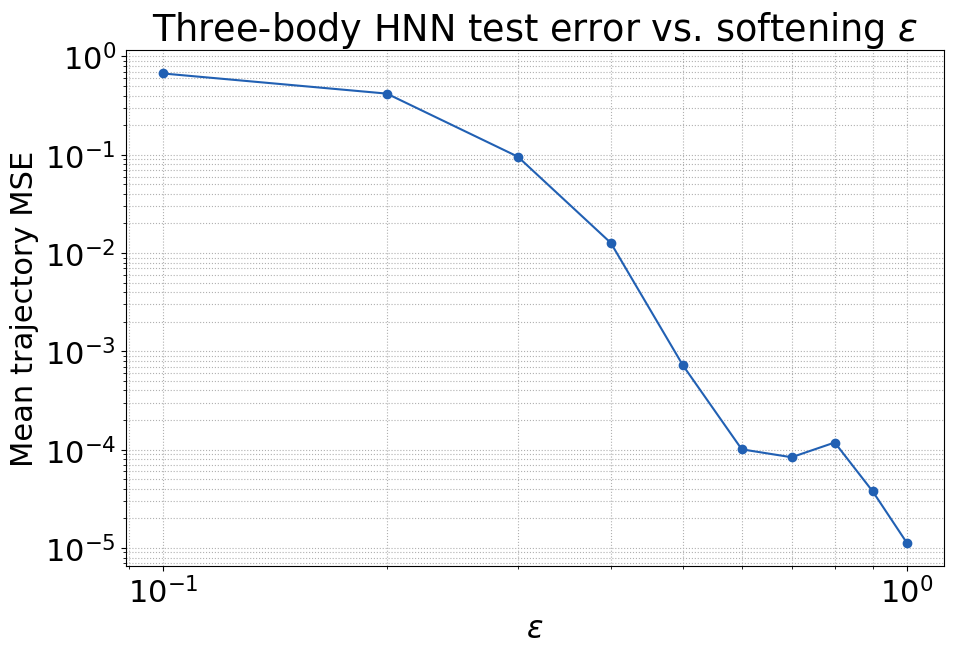

In [25]:
mean_err = errors.mean(axis=1)
std_err = errors.std(axis=1)

plt.figure(figsize=(10,7))
plt.loglog(epsilons, mean_err, "o-", c=COLORS["dark_blue"])  # loglog usually nice for eps sweeps
plt.xlabel(r"$\epsilon$")
plt.ylabel("Mean trajectory MSE")
plt.title("Three-body HNN test error vs. softening $\epsilon$")
plt.grid(True, which="both", ls=":")
plt.tight_layout()
#plt.savefig(CKPT_DIR / "three_body_hnn_epsilon_sweep_t1-5_dt-0-005.pdf", dpi=300)
plt.show()

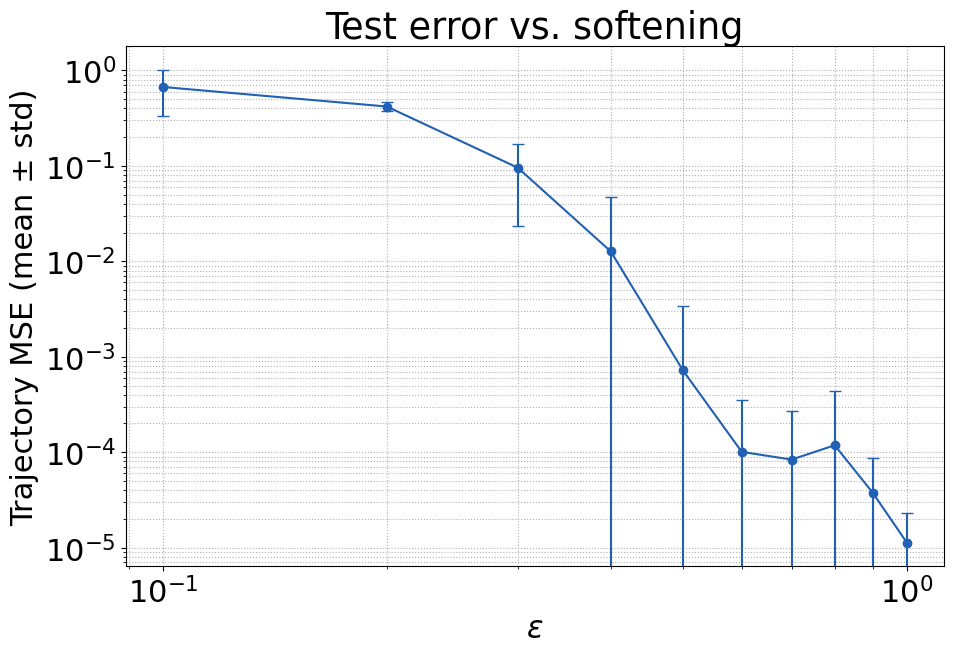

In [26]:
plt.figure(figsize=(10,7))
plt.errorbar(
    epsilons,
    mean_err,
    yerr=std_err,
    fmt="o-",
    c=COLORS["dark_blue"],
    capsize=4,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\epsilon$")
plt.ylabel("Trajectory MSE (mean ± std)")
plt.title("Test error vs. softening")
plt.grid(True, which="both", ls=":")
plt.tight_layout()
#plt.savefig("epsilon_range_test_errorbar.pdf")
plt.show()

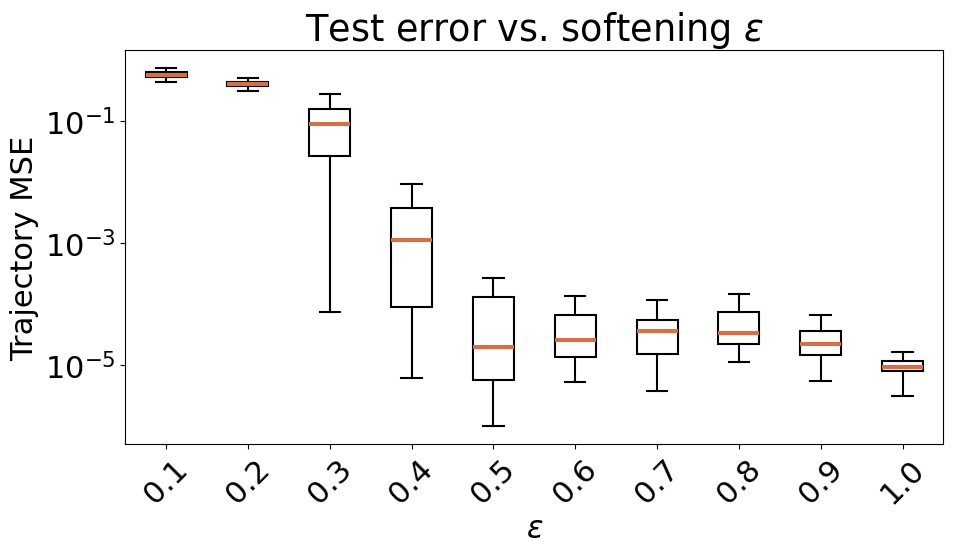

In [39]:
plt.figure(figsize=(10,6))
positions = np.arange(len(epsilons)) + 1  # 1..n

plt.boxplot(
    [errors[i] for i in range(len(epsilons))],
    positions=positions,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="white", color="black", linewidth=1.5),
    whiskerprops=dict(color="black", linewidth=1.5),
    capprops=dict(color="black", linewidth=1.5),
    medianprops=dict(color=COLORS["orange"], linewidth=3),
)

plt.xticks(positions, [f"{eps:.1f}" for eps in epsilons], rotation=45)
plt.yscale("log")
plt.xlabel(r"$\epsilon$")
plt.ylabel("Trajectory MSE")
plt.title("Test error vs. softening $\epsilon$")
plt.tight_layout()
#plt.savefig(CKPT_DIR / "epsilon_range_test_boxplot_t1-5_dt-0-005.pdf")
plt.show()

# Plot lambdas

In [27]:
RESULTS_DIR = Path(CKPT_DIR / "results_128_trajectories_T1-5_dt-0-005")

In [28]:
def load_all_growth_rates(results_dir=RESULTS_DIR):
    epsilons = []
    all_lambdas = []

    for npz_file in sorted(results_dir.glob("eps_*_results.npz")):
        data = np.load(npz_file)
        eps = float(data["epsilon"])
        lam = data["lambdas"]  # [N_IC]
        epsilons.append(eps)
        all_lambdas.append(lam)

    epsilons = np.array(epsilons)
    lambdas = np.stack(all_lambdas, axis=0)  # [n_eps, N_IC]
    return epsilons, lambdas

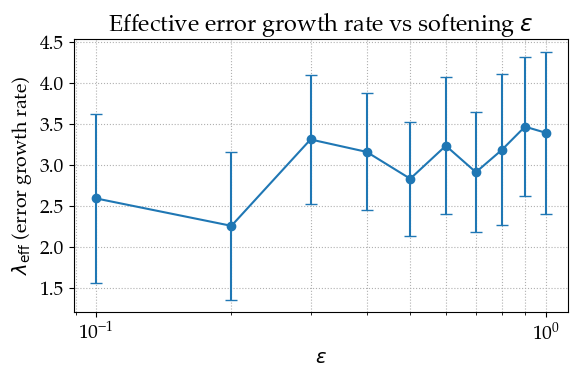

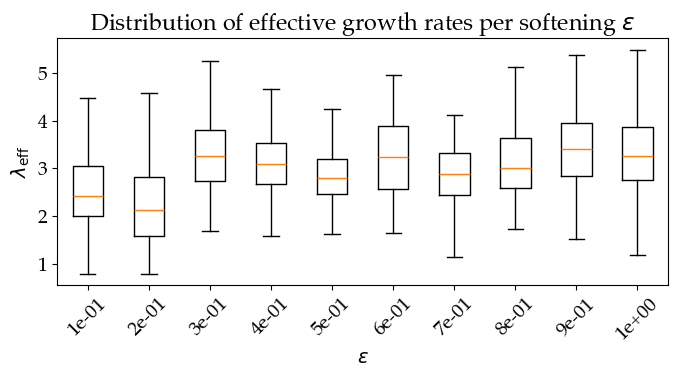

In [29]:
epsilons, lambdas = load_all_growth_rates()
mean_lam = lambdas.mean(axis=1)
std_lam  = lambdas.std(axis=1)

# 1) mean ± std
plt.figure(figsize=(6,4))
plt.errorbar(
    epsilons,
    mean_lam,
    yerr=std_lam,
    fmt="o-",
    capsize=4,
)
plt.xscale("log")
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$\lambda_{\mathrm{eff}}$ (error growth rate)")
plt.title("Effective error growth rate vs softening $\epsilon$")
plt.grid(True, which="both", ls=":")
plt.tight_layout()
plt.show()

# 2) boxplot to show distribution
plt.figure(figsize=(7,4))
positions = np.arange(len(epsilons)) + 1
plt.boxplot(
    [lambdas[i] for i in range(len(epsilons))],
    positions=positions,
    showfliers=False,
)
plt.xticks(positions, [f"{eps:.0e}" for eps in epsilons], rotation=45)
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$\lambda_{\mathrm{eff}}$")
plt.title("Distribution of effective growth rates per softening $\epsilon$")
plt.tight_layout()
plt.show()

# Videos of the predicted trajectories

In [56]:
key, subkey = jax.random.split(key)
y0s = sample_ic_batch(subkey, system_params, N=1)
length_factor = 20
eps = 0.1

model, aux = load_model(epsilon=eps, model_save_name=model_save_name, model_like=model_like)

In [57]:
t_eval, y_true = true_trajectories(ic_batch=y0s, t0=0, t1=length_factor*T1, num_steps=length_factor*NUM_STEPS, eps=eps, system_params=system_params)

y_pred = predict_hnn_trajectories(model=model, ic_batch=y0s, t0=0, t1=length_factor*T1, num_steps=length_factor*NUM_STEPS, eps=eps, system_params=system_params)

In [58]:
y_true.shape

(1, 100020, 18)

In [94]:
def animate_mass_spring_3d_jax(
    y,                         # jnp.ndarray or np.ndarray with shape [N, 6*M]
    y2=None,                   # optional second trajectory for comparison
    save_path="mass_springs_3d.gif",
    fps=30,
    dpi=120,
    mass_markersize=8,
    trail_len=None,            # e.g. 50 to show recent trajectory; None for no trails
    title=None,
    tight_limits=True,
    margin=0.1,                # padding fraction for axes
    frame_step=16,             # subsample frames
):

    # Bring data to host NumPy
    y_np = np.asarray(jax.device_get(y))
    assert y_np.ndim == 2, "y must be [N, 6*M]"
    N, D = y_np.shape
    assert D % 6 == 0, "State dimension must be divisible by 6 (qx,qy,qz,...,px,py,pz,...)"
    M = D // 6

    # Process second trajectory if provided
    y2_np = None
    if y2 is not None:
        y2_np = np.asarray(jax.device_get(y2))
        assert y2_np.shape == y_np.shape, "y2 must have same shape as y"

    # Subsample frames
    idx = np.arange(0, N, frame_step, dtype=int)
    y_np = y_np[idx]
    if y2_np is not None:
        y2_np = y2_np[idx]
    N = y_np.shape[0]

    # Unpack primary trajectory
    pos = y_np[:, : 3 * M].reshape(N, M, 3)        # [N, M, 3] -> (x,y,z)

    # Unpack second trajectory if present
    pos2 = None
    if y2_np is not None:
        pos2 = y2_np[:, : 3 * M].reshape(N, M, 3)

    # Axis limits (considering both trajectories)
    if tight_limits:
        all_pos = [pos]
        if pos2 is not None:
            all_pos.append(pos2)
        all_pos_concat = np.concatenate(all_pos, axis=0)  # [N_total, M, 3]

        xmin = all_pos_concat[:, :, 0].min()
        xmax = all_pos_concat[:, :, 0].max()
        ymin = all_pos_concat[:, :, 1].min()
        ymax = all_pos_concat[:, :, 1].max()
        zmin = all_pos_concat[:, :, 2].min()
        zmax = all_pos_concat[:, :, 2].max()

        dx = xmax - xmin
        dy = ymax - ymin
        dz = zmax - zmin

        pad_x = margin * (dx if dx > 0 else 1.0)
        pad_y = margin * (dy if dy > 0 else 1.0)
        pad_z = margin * (dz if dz > 0 else 1.0)

        xmin, xmax = xmin - pad_x, xmax + pad_x
        ymin, ymax = ymin - pad_y, ymax + pad_y
        zmin, zmax = zmin - pad_z, zmax + pad_z

    # Figure + 3D axes
    fig = plt.figure(figsize=(6, 6), dpi=dpi)
    ax = fig.add_subplot(111, projection="3d")
    if title:
        ax.set_title(title)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    if tight_limits:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_zlim(zmin, zmax)

    # Colors for masses (mass 1 gets different color)
    mass_colors = ['#1f77b4', '#ff7f0e', '#1f77b4']  # blue, orange, blue
    if M > 3:
        # simple extension if more masses: repeat colors
        mass_colors = (mass_colors * ((M + 2) // 3))[:M]

    # --- create artists for primary trajectory ---
    mass_scatters = []
    for i in range(M):
        scatter, = ax.plot(
            [], [], [], "s",
            ms=mass_markersize * 0.8,
            color=mass_colors[i],
            alpha=0.5,
            label="Unobserved mass (true)" if i == 1 and M == 3 else None,
            zorder=4,
        )
        mass_scatters.append(scatter)

    # trails
    trail_lines = None
    if trail_len and trail_len > 0:
        trail_lines = [
            ax.plot([], [], [], "--", alpha=0.4, color=mass_colors[m], lw=1)[0]
            for m in range(M)
        ]

    time_text = fig.text(0.02, 0.95, "", transform=fig.transFigure, va="top")

    # --- artists for second trajectory (if present) ---
    mass_scatters2 = None
    trail_lines2 = None

    if pos2 is not None:
        mass_scatters2 = []
        for i in range(M):
            scatter, = ax.plot(
                [], [], [], "o",
                ms=mass_markersize,
                color=mass_colors[i],
                label="Unobserved mass (predicted)" if i == 1 and M == 3 else None,
                zorder=5,
            )
            mass_scatters2.append(scatter)

        if trail_len and trail_len > 0:
            trail_lines2 = [
                ax.plot([], [], [], "-", alpha=0.6, color=mass_colors[m], lw=1)[0]
                for m in range(M)
            ]

    if M == 3:
        ax.legend(loc="upper right")

    # --- init function ---
    def init():

        for scatter in mass_scatters:
            scatter.set_data([], [])
            scatter.set_3d_properties([])

        if trail_lines:
            for ln in trail_lines:
                ln.set_data([], [])
                ln.set_3d_properties([])

        if mass_scatters2:
            for scatter in mass_scatters2:
                scatter.set_data([], [])
                scatter.set_3d_properties([])

        if trail_lines2:
            for ln in trail_lines2:
                ln.set_data([], [])
                ln.set_3d_properties([])

        time_text.set_text("")

        artists = [*mass_scatters]
        if trail_lines:
            artists.extend(trail_lines)
        if mass_scatters2:
            artists.extend(mass_scatters2)
        if trail_lines2:
            artists.extend(trail_lines2)
        artists.append(time_text)
        return artists

    # --- update function ---
    def update(frame):

        # primary trajectory masses
        for i, scatter in enumerate(mass_scatters):
            scatter.set_data([pos[frame, i, 0]], [pos[frame, i, 1]])
            scatter.set_3d_properties([pos[frame, i, 2]])

        # primary trails
        if trail_lines:
            start = max(0, frame - trail_len + 1)
            for m, ln in enumerate(trail_lines):
                ln.set_data(
                    pos[start:frame + 1, m, 0],
                    pos[start:frame + 1, m, 1],
                )
                ln.set_3d_properties(
                    pos[start:frame + 1, m, 2]
                )

        # second trajectory (if present)
        if mass_scatters2:
            for i, scatter in enumerate(mass_scatters2):
                scatter.set_data([pos2[frame, i, 0]], [pos2[frame, i, 1]])
                scatter.set_3d_properties([pos2[frame, i, 2]])

            if trail_lines2:
                start = max(0, frame - trail_len + 1)
                for m, ln in enumerate(trail_lines2):
                    ln.set_data(
                        pos2[start:frame + 1, m, 0],
                        pos2[start:frame + 1, m, 1],
                    )
                    ln.set_3d_properties(
                        pos2[start:frame + 1, m, 2]
                    )

        artists = [*mass_scatters]
        if trail_lines:
            artists.extend(trail_lines)
        if mass_scatters2:
            artists.extend(mass_scatters2)
        if trail_lines2:
            artists.extend(trail_lines2)
        artists.append(time_text)

        return artists

    # NOTE: blitting is troublesome with 3D + quiver → use blit=False
    anim = animation.FuncAnimation(
        fig, update, init_func=init, frames=N, interval=1000 / fps, blit=False
    )

    # Save
    save_path = str(Path(save_path))
    ext = Path(save_path).suffix.lower()
    if ext == ".gif":
        try:
            writer = animation.PillowWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError(
                "Saving GIF requires Pillow. Install with `pip install pillow`."
            ) from e
        anim.save(save_path, writer=writer, dpi=dpi)
    elif ext == ".mp4":
        try:
            writer = animation.FFMpegWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError(
                "Saving MP4 requires ffmpeg available on PATH."
            ) from e
        anim.save(save_path, writer=writer, dpi=dpi)
    else:
        plt.close(fig)
        raise ValueError("save_path must end with .gif or .mp4")

    plt.close(fig)
    return save_path, anim


In [95]:
# path, anim = animate_mass_spring_3d_jax(
#     y=y_true[0],
#     y2=y_pred[0],
#     save_path=f"checkpoints/plummersoftening/epsilon_range_test/eps_{eps:.1f}/trajectory_comparison".replace(".", "-") + ".mp4",
#     trail_len=40,
#     frame_step=30,
#     title="",
# )
# print("Saved to:", path)

Saved to: checkpoints/plummersoftening/epsilon_range_test/eps_0-1/trajectory_comparison.mp4


0.1